# LDA sur MNIST (784 Dimensions)
Ce notebook démontre l'efficacité de la LDA pour réduire la dimensionnalité de **784D à 9D** tout en préservant les performances de classification.

## Objectif
- Travailler sur le **vrai MNIST 28×28 pixels** via `fetch_openml('mnist_784')`
- Garder une structure simple et lisible pour l'oral
- Montrer que la LDA conserve l'information discriminante utile

## Idée principale
La LDA cherche à maximiser la séparation entre les classes en projetant les données sur des axes discriminants pertinents.

## Plan
1. Chargement du vrai MNIST (784D)
2. Normalisation des données
3. Application de la LDA
4. Classification et évaluation
5. Visualisation en 2D

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Chargement des données (Vrai MNIST 784D)
print("📥 Chargement de MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
y = y.astype(int)

# Sous-échantillonnage pour la rapidité de démo (5000 images)
indices = np.random.choice(len(X), 5000, replace=False)
X, y = X[indices], y[indices]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Format des données: {X_train.shape}")
print(f"Nombre de classes: {len(np.unique(y))}")
print(f"Nombre de features: {X_train.shape[1]} (28×28 pixels = 784)")

📥 Chargement de MNIST...
Format des données: (4000, 784)
Nombre de classes: 10
Nombre de features: 784 (28×28 pixels = 784)


In [2]:
# 2. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Normalisation appliquée avec succès")
print(f"   Train - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"   Test  - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

✅ Normalisation appliquée avec succès
   Train - Mean: -0.000000, Std: 0.910539
   Test  - Mean: 0.003062, Std: 1.151528


In [3]:
# 3. Application de la LDA (C-1 = 9 composantes)
lda = LinearDiscriminantAnalysis(n_components=9)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

variance_ratio = lda.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

print(f"Réduction: {X_train_scaled.shape[1]}D -> {X_train_lda.shape[1]}D")
print(f"Variance expliquée cumulée: {np.sum(variance_ratio)*100:.2f}%")

variance_df = pd.DataFrame({
    'Composante': range(1, len(variance_ratio) + 1),
    'Variance expliquée (%)': variance_ratio * 100,
    'Variance cumulée (%)': cumulative_variance * 100
})
print("\nVariance expliquée par composante:")
print(variance_df.to_string(index=False))

Réduction: 784D -> 9D
Variance expliquée cumulée: 100.00%

Variance expliquée par composante:
 Composante  Variance expliquée (%)  Variance cumulée (%)
          1               23.000886             23.000886
          2               20.473270             43.474156
          3               15.814496             59.288653
          4               11.006223             70.294876
          5                9.737525             80.032401
          6                7.546646             87.579047
          7                5.430775             93.009822
          8                4.074631             97.084453
          9                2.915547            100.000000


In [4]:
# 4. Classification et Évaluation
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_lda, y_train)
y_pred = clf.predict(X_test_lda)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")
print("\nMatrice de Confusion:")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de Classification:")
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 83.50%

Matrice de Confusion:
[[ 93   0   1   0   0   0   3   2   0   0]
 [  0 111   1   0   0   0   0   0   4   0]
 [  1   3  87   6   1   2   2   1   2   0]
 [  0   1   1  82   1   6   1   5   1   2]
 [  0   1   2   0  85   1   1   0   1   6]
 [  1   1   5  10   1  60   1   1   7   3]
 [  2   0   8   0   1   1  81   0   3   0]
 [  2   1   3   4   1   0   0  86   0   7]
 [  0   8   1   5   1   3   1   0  75   0]
 [  1   1   1   1  14   1   0   4   1  75]]

Rapport de Classification:
              precision    recall  f1-score   support

           0      0.930     0.939     0.935        99
           1      0.874     0.957     0.914       116
           2      0.791     0.829     0.809       105
           3      0.759     0.820     0.788       100
           4      0.810     0.876     0.842        97
           5      0.811     0.667     0.732        90
           6      0.900     0.844     0.871        96
           7      0.869     0.827     0.847       104
           8  

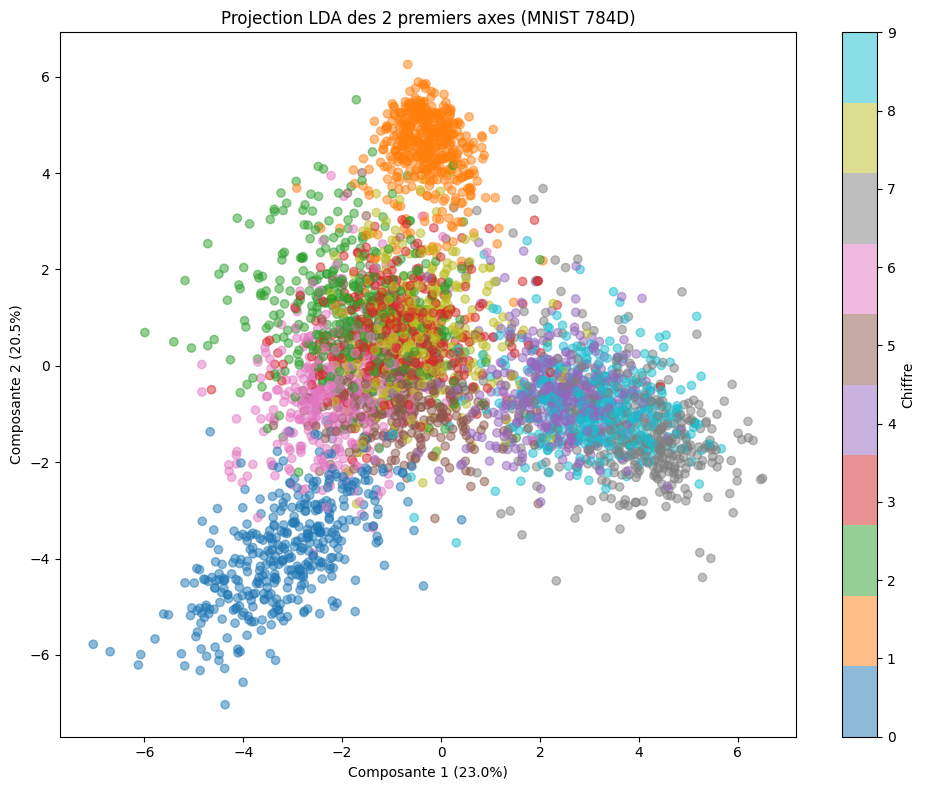

✅ Visualisation 2D réussie


In [5]:
# 5. Visualisation 2D
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_train_lda_2d = lda_2d.fit_transform(X_train_scaled, y_train)
X_test_lda_2d = lda_2d.transform(X_test_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_train_lda_2d[:, 0],
    X_train_lda_2d[:, 1],
    c=y_train,
    cmap='tab10',
    alpha=0.5
)
plt.colorbar(scatter, label='Chiffre')
plt.title("Projection LDA des 2 premiers axes (MNIST 784D)")
plt.xlabel(f"Composante 1 ({lda_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Composante 2 ({lda_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

print("✅ Visualisation 2D réussie")